## Imports

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from utils import dataloader, connect_gt_and_pred, calculate_error_distributions
from statsforecast import StatsForecast
from neuralforecast import NeuralForecast
from neuralforecast.losses.numpy import mae, mse, rmse

## Load model and environment

In [2]:
config = {
        'normalize': False,
        'horizon': 3,
        'snippet_length': 24,
        'train_dataset': 'ICU_train',
        'test_dataset': 'ICU_test_10',
}

horizon = config['horizon']
snippet_length = config['snippet_length']

In [7]:
# model_path = "models/2025_06_04_17_34" # TimesNet 20k steps
# model_path = "models/2025_06_04_23_33" # iTransformer 20k steps
# model_path = 'models/2025_12_18_04_34_TimesNet_21_3_5000/'
model_path = 'models/2025_12_18_23_22_45_TimesNet_21_3_50000/'

In [8]:
nf = NeuralForecast.load(path=model_path)

print("validing date and time: ", model_path[7:])
print("valided model(s): ", nf.models)


Seed set to 1


validing date and time:  2025_12_18_23_22_45_TimesNet_21_3_50000/
valided model(s):  [TimesNet]


## Load and prep test data

In [9]:
print('Loading dataset: ', config['test_dataset'])
data_test = dataloader(config=config, train=False)
Y_df_test = data_test.find_all_continuous_snippets(hours=snippet_length)
print('Done!')

Loading dataset:  ICU_test_10


Done!


In [10]:
# drop last horizon length y values for prediction
ids_to_drop = [i for i in range(len(Y_df_test)) if i % snippet_length >= snippet_length-horizon]
ids_to_drop_for_comparison = [i for i in range(len(Y_df_test)) if i % snippet_length < snippet_length-horizon]
Y_df_gt_window = Y_df_test.drop(ids_to_drop)
Y_df_gt_horizon = Y_df_test.drop(ids_to_drop_for_comparison)

In [11]:
input_window_length = snippet_length - horizon
chunk_size = 32 * input_window_length  # Process 32 complete windows at a time
if len(Y_df_gt_window) % chunk_size != 0:
    final_length = (len(Y_df_gt_window) // chunk_size) * chunk_size
    Y_df_gt_window_chunked = Y_df_gt_window.iloc[:final_length].reset_index(drop=True)
else:
    Y_df_gt_window_chunked = Y_df_gt_window

## Run prediction

In [12]:
Y_hat_df_2 = nf.predict(df=Y_df_gt_window_chunked).reset_index()


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [13]:
Y_hat_df_2.head(10)

,index,unique_id,ds,TimesNet-median,TimesNet-lo-98,TimesNet-lo-97,TimesNet-lo-95,TimesNet-hi-95,TimesNet-hi-97,TimesNet-hi-98
0,0,0202-01_01_7360,2020-01-01 21:00:00,0.000059,-0.000017,-8.295028e-06,0.000001,0.000114,0.000126,0.000134
1,1,0202-01_01_7360,2020-01-01 22:00:00,0.000055,-0.000023,-1.547928e-05,-0.000006,0.000140,0.000157,0.000172
2,2,0202-01_01_7360,2020-01-01 23:00:00,0.000058,-0.000029,-2.188677e-05,-0.000013,0.000173,0.000196,0.000213
3,3,0202-01_01_7361,2020-01-01 22:00:00,0.000074,-0.000002,5.198406e-06,0.000018,0.000134,0.000142,0.000151
4,4,0202-01_01_7361,2020-01-01 23:00:00,0.000070,-0.000007,3.241657e-07,0.000008,0.000158,0.000174,0.000188
5,5,0202-01_01_7361,2020-01-02 00:00:00,0.000076,-0.000007,-1.651893e-06,0.000006,0.000192,0.000213,0.000235
6,6,0202-01_01_7362,2020-01-01 23:00:00,0.000192,-0.000105,-7.461955e-05,-0.000046,0.000509,0.000570,0.000615
7,7,0202-01_01_7362,2020-01-02 00:00:00,0.000163,-0.000119,-1.000949e-04,-0.000071,0.000585,0.000652,0.000716
8,8,0202-01_01_7362,2020-01-02 01:00:00,0.000179,-0.000177,-1.458922e-04,-0.000112,0.000698,0.000797,0.000902
9,9,0202-01_01_7363,2020-01-02 00:00:00,0.000032,-0.000096,-8.289135e-05,-0.000064,0.000308,0.000378,0.000416


## Clip and denormalize predictions

In [14]:
for model in nf.models:
    Y_hat_df_2.rename(columns={f'{model}-median': str(model)}, inplace=True)
    Y_hat_df_2[str(model)] = Y_hat_df_2[str(model)].clip(lower=0.0)

if config['normalize']:

    # denormalize GT values
    Y_df_gt_horizon['y'] = data_test.scaler.inverse_transform(Y_df_gt_horizon['y'].values.reshape(-1,1))
    Y_df_test['y'] = data_test.scaler.inverse_transform(Y_df_test['y'].values.reshape(-1,1))
    
    # denormalize predicted values
    for model in nf.models:
        Y_hat_df_2[str(model)] = data_test.scaler.inverse_transform(Y_hat_df_2[str(model)].values.reshape(-1,1))
        Y_hat_df_2[f'{model}-lo-95'] = data_test.scaler.inverse_transform(Y_hat_df_2[f'{model}-lo-95'].values.reshape(-1,1))
        Y_hat_df_2[f'{model}-hi-95'] = data_test.scaler.inverse_transform(Y_hat_df_2[f'{model}-hi-95'].values.reshape(-1,1))
        Y_hat_df_2[f'{model}-lo-97'] = data_test.scaler.inverse_transform(Y_hat_df_2[f'{model}-lo-97'].values.reshape(-1,1))
        Y_hat_df_2[f'{model}-hi-97'] = data_test.scaler.inverse_transform(Y_hat_df_2[f'{model}-hi-97'].values.reshape(-1,1))
        Y_hat_df_2[f'{model}-lo-98'] = data_test.scaler.inverse_transform(Y_hat_df_2[f'{model}-lo-98'].values.reshape(-1,1))
        Y_hat_df_2[f'{model}-hi-98'] = data_test.scaler.inverse_transform(Y_hat_df_2[f'{model}-hi-98'].values.reshape(-1,1))

## Calculate and plot metrics and results

In [15]:
# calculate metrics
metrics_cols = ['Model Name', 'MAE', 'MSE', 'RMSE']
metrics = pd.DataFrame(columns=metrics_cols)
for model in nf.models:
    model_metrics = {metrics_cols[0]: str(model)}
    model_metrics['MAE'] = mae(Y_hat_df_2[str(model)], Y_df_gt_horizon['y'])
    model_metrics['MSE'] = mse(Y_hat_df_2[str(model)], Y_df_gt_horizon['y'])
    model_metrics['RMSE'] = rmse(Y_hat_df_2[str(model)], Y_df_gt_horizon['y'])

    model_metrics_df = pd.DataFrame(model_metrics, index=[0])
    metrics = pd.concat([metrics, model_metrics_df], ignore_index=True)

C:\Users\msz30\AppData\Local\Temp\ipykernel_23352\1980489120.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics = pd.concat([metrics, model_metrics_df], ignore_index=True)


In [16]:
df_to_plot_2 = connect_gt_and_pred(df_gt=Y_df_test, df_pred=Y_hat_df_2, snippet_length=snippet_length, horizon=horizon)

Started merging function
Cutoff timestamps appended


  0%|          | 0/23808 [00:00<?, ?it/s]

100%|██████████| 23808/23808 [00:12<00:00, 1914.52it/s]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [17]:
prediction_graphs = StatsForecast.plot(Y_df_test, df_to_plot_2.drop(columns=['y', 'cutoff', 'level_0']), models=['TimesNet-lo-97', 'TimesNet-hi-97', 'TimesNet-lo-98', 'TimesNet-hi-98', 'TimesNet-lo-95', 'TimesNet-hi-95'], max_insample_length=1260)
histograms, means_stds_df = calculate_error_distributions(Y_df_gt_horizon, Y_hat_df_2, models=nf, horizon=horizon)
plt.close(histograms)





  Model name Statistic       t+1       t+2       t+3
0   TimesNet      Mean -0.000002  0.000005  0.000008
1   TimesNet       Std  0.000390  0.000387  0.000387


## Visualize

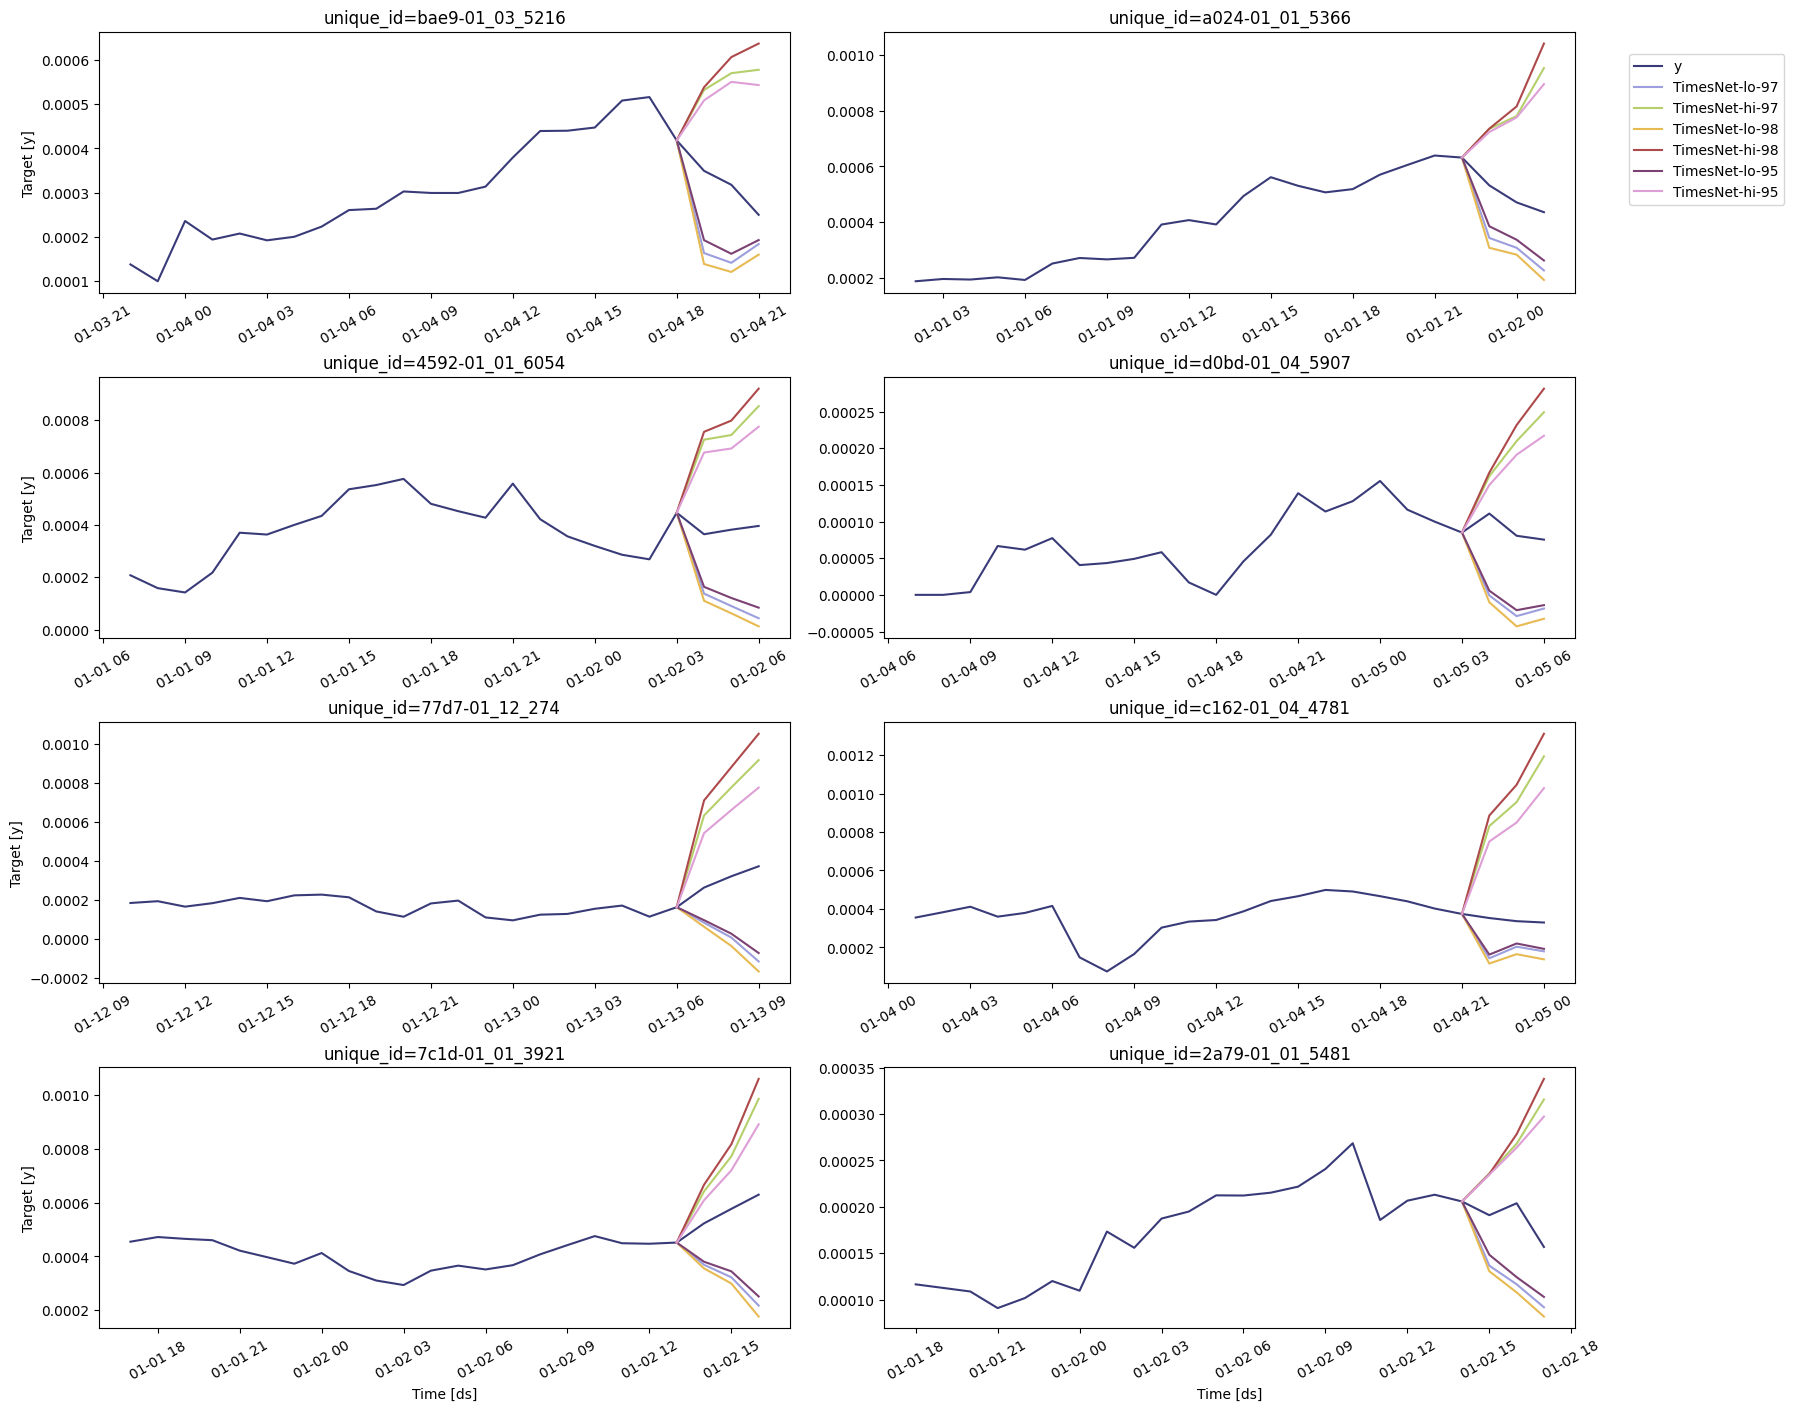

In [18]:
prediction_graphs

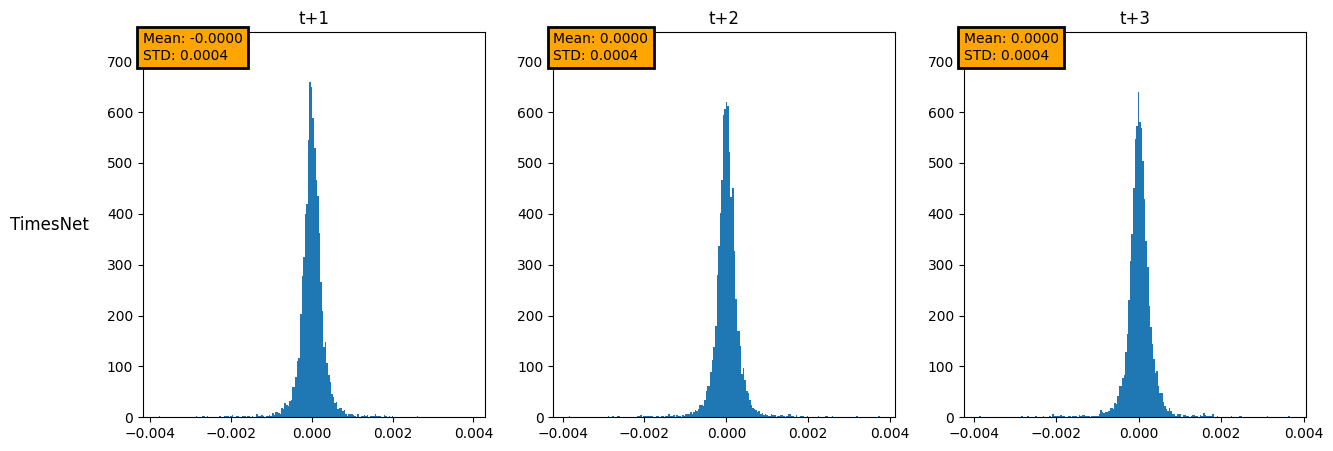

In [19]:
histograms

# Bootstrap intervals

## Load and prep validation dataset

In [20]:
print('Loading dataset: ICU_validation dataset')
data_valid = dataloader(config=config, train=False, valid=True)
Y_df_valid = data_valid.find_all_continuous_snippets(hours=snippet_length)
print('Done!')

Loading dataset: ICU_validation dataset


Done!


In [21]:
# drop last horizon length y values for prediction
ids_to_drop = [i for i in range(len(Y_df_valid)) if i % snippet_length >= snippet_length-horizon]
ids_to_drop_for_comparison = [i for i in range(len(Y_df_valid)) if i % snippet_length < snippet_length-horizon]
Y_df_valid_gt_window = Y_df_valid.drop(ids_to_drop)
Y_df_valid_gt_horizon = Y_df_valid.drop(ids_to_drop_for_comparison)

In [22]:
if len(Y_df_valid_gt_window) % chunk_size != 0:
    final_length = (len(Y_df_valid_gt_window) // chunk_size) * chunk_size
    Y_df_valid_gt_window_chunked = Y_df_valid_gt_window.iloc[:final_length].reset_index(drop=True)
else:
    Y_df_valid_gt_window_chunked = Y_df_valid_gt_window

## Predict on validation dataset

In [23]:
Y_hat_df_valid = nf.predict(df=Y_df_valid_gt_window_chunked).reset_index()

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [24]:
Y_hat_df_valid

,index,unique_id,ds,TimesNet-median,TimesNet-lo-98,TimesNet-lo-97,TimesNet-lo-95,TimesNet-hi-95,TimesNet-hi-97,TimesNet-hi-98
0,0,00ed-01_01_3933,2020-01-01 21:00:00,0.000191,0.000055,0.000073,0.000079,0.000536,0.000600,0.000651
1,1,00ed-01_01_3933,2020-01-01 22:00:00,0.000177,-0.000012,0.000016,0.000036,0.000579,0.000663,0.000733
2,2,00ed-01_01_3933,2020-01-01 23:00:00,0.000211,-0.000190,-0.000140,-0.000081,0.000718,0.000837,0.000948
3,3,00ed-01_01_3934,2020-01-01 22:00:00,0.000209,0.000129,0.000135,0.000156,0.000467,0.000537,0.000589
4,4,00ed-01_01_3934,2020-01-01 23:00:00,0.000224,0.000003,0.000045,0.000076,0.000706,0.000825,0.000935
...,...,...,...,...,...,...,...,...,...,...
26779,26779,fe3a-01_01_3371,2020-01-02 21:00:00,0.000125,-0.000049,-0.000030,-0.000011,0.000259,0.000278,0.000296
26780,26780,fe3a-01_01_3371,2020-01-02 22:00:00,0.000126,-0.000055,-0.000034,-0.000014,0.000293,0.000322,0.000346
26781,26781,fe3a-01_02_3372,2020-01-02 21:00:00,0.000102,-0.000013,0.000003,0.000017,0.000183,0.000198,0.000210
26782,26782,fe3a-01_02_3372,2020-01-02 22:00:00,0.000104,-0.000023,-0.000006,0.000008,0.000218,0.000238,0.000257


## Clip and denormalize predictions

In [25]:
for model in nf.models:
    Y_hat_df_2.rename(columns={f'{model}-median': str(model)}, inplace=True)
    Y_hat_df_valid[str(f"{model}-median")] = Y_hat_df_valid[str(f"{model}-median")].clip(lower=0.0)

if config['normalize']:

    # denormalize GT values
    Y_df_valid_gt_horizon['y'] = data_valid.scaler.inverse_transform(Y_df_valid_gt_horizon['y'].values.reshape(-1,1))
    Y_df_valid['y'] = data_valid.scaler.inverse_transform(Y_df_valid['y'].values.reshape(-1,1))
    
    # denormalize predicted values
    for model in nf.models:
        Y_hat_df_valid[str(model)] = data_valid.scaler.inverse_transform(Y_hat_df_valid[str(model)].values.reshape(-1,1))
        Y_hat_df_valid[f'{model}-lo-95'] = data_valid.scaler.inverse_transform(Y_hat_df_valid[f'{model}-lo-95'].values.reshape(-1,1))
        Y_hat_df_valid[f'{model}-hi-95'] = data_valid.scaler.inverse_transform(Y_hat_df_valid[f'{model}-hi-95'].values.reshape(-1,1))

## Calculate residuals

In [51]:
Y_df_valid_gt_horizon_sorted = Y_df_valid_gt_horizon.sort_values(['unique_id', 'ds']).reset_index(drop=True)
Y_hat_df_valid_sorted = Y_hat_df_valid.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# residuals = Y_df_valid_gt_horizon_sorted['y'] - Y_hat_df_valid_sorted[str(nf.models[0])]

residuals = []
for i, val in enumerate(Y_hat_df_valid_sorted[f"{model}-median"]):
    diff = Y_df_valid_gt_horizon_sorted['y'][i] - val
    if pd.Series([diff]).isna().any():
        print(i)
        print(Y_df_valid_gt_horizon_sorted['y'][i])
        print(val)
        continue
    residuals.append(diff)


## Calculate 5th and 95th percentile, and concatenate results

In [52]:
runs = 1000

Y_hat_df_2_percentiles = Y_hat_df_2.copy(deep=True)


samples = []
for _ in range(runs):
    sampled = Y_hat_df_2_percentiles[str(nf.models[0])] + np.random.choice(residuals, size=len(Y_hat_df_2_percentiles[str(nf.models[0])]), replace=True)
    samples.append(sampled)

samples = np.stack(samples)
lower = np.percentile(samples, 5, axis=0)
lower = np.clip(lower, a_min=1e-7, a_max=None)
upper = np.percentile(samples, 95, axis=0)
median = np.percentile(samples, 50, axis=0)

Y_hat_df_2_percentiles['95'] = upper
Y_hat_df_2_percentiles['05'] = lower
Y_hat_df_2_percentiles['median'] = median

In [26]:
Y_hat_df_2_percentiles = Y_hat_df_2

In [27]:
Y_hat_df_2_percentiles.head(10)

,index,unique_id,ds,TimesNet,TimesNet-lo-98,TimesNet-lo-97,TimesNet-lo-95,TimesNet-hi-95,TimesNet-hi-97,TimesNet-hi-98
0,0,0202-01_01_7360,2020-01-01 21:00:00,0.000059,-0.000017,-8.295028e-06,0.000001,0.000114,0.000126,0.000134
1,1,0202-01_01_7360,2020-01-01 22:00:00,0.000055,-0.000023,-1.547928e-05,-0.000006,0.000140,0.000157,0.000172
2,2,0202-01_01_7360,2020-01-01 23:00:00,0.000058,-0.000029,-2.188677e-05,-0.000013,0.000173,0.000196,0.000213
3,3,0202-01_01_7361,2020-01-01 22:00:00,0.000074,-0.000002,5.198406e-06,0.000018,0.000134,0.000142,0.000151
4,4,0202-01_01_7361,2020-01-01 23:00:00,0.000070,-0.000007,3.241657e-07,0.000008,0.000158,0.000174,0.000188
5,5,0202-01_01_7361,2020-01-02 00:00:00,0.000076,-0.000007,-1.651893e-06,0.000006,0.000192,0.000213,0.000235
6,6,0202-01_01_7362,2020-01-01 23:00:00,0.000192,-0.000105,-7.461955e-05,-0.000046,0.000509,0.000570,0.000615
7,7,0202-01_01_7362,2020-01-02 00:00:00,0.000163,-0.000119,-1.000949e-04,-0.000071,0.000585,0.000652,0.000716
8,8,0202-01_01_7362,2020-01-02 01:00:00,0.000179,-0.000177,-1.458922e-04,-0.000112,0.000698,0.000797,0.000902
9,9,0202-01_01_7363,2020-01-02 00:00:00,0.000032,-0.000096,-8.289135e-05,-0.000064,0.000308,0.000378,0.000416


## Prepare and plot results

In [28]:
df_to_plot_2 = connect_gt_and_pred(df_gt=Y_df_test, df_pred=Y_hat_df_2_percentiles, snippet_length=snippet_length, horizon=horizon)

Started merging function
Cutoff timestamps appended


  3%|▎         | 713/23808 [00:00<00:06, 3441.28it/s]

100%|██████████| 23808/23808 [00:12<00:00, 1840.57it/s]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [31]:
prediction_graphs = StatsForecast.plot(Y_df_test, df_to_plot_2.drop(columns=['y', 'cutoff', 'level_0']), max_insample_length=1260)

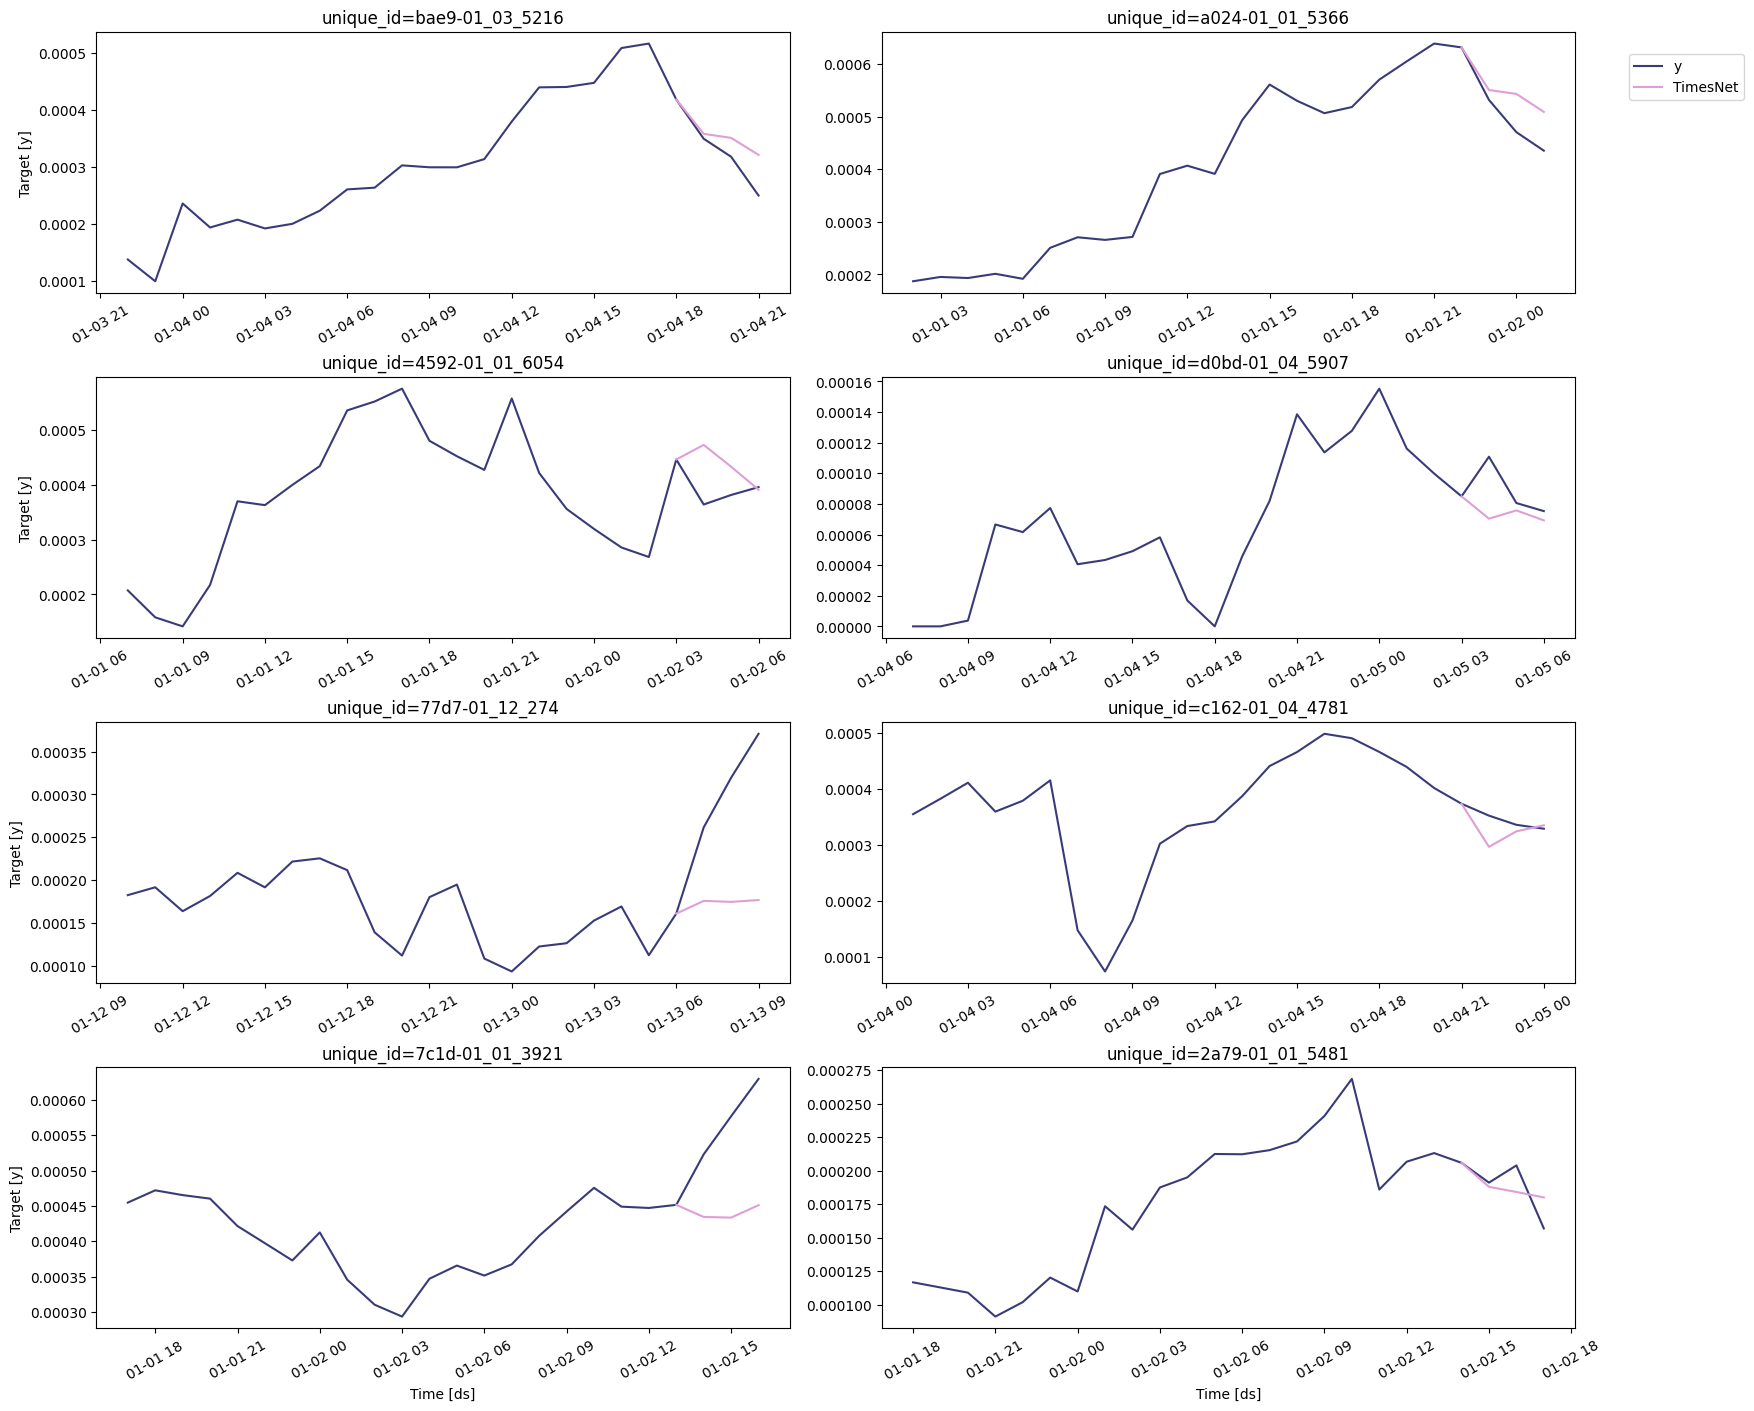

In [32]:
prediction_graphs

In [29]:
model_name = str(nf.models[0])

In [30]:
Y_hat_df_2_percentiles_merged = Y_hat_df_2_percentiles.merge(
    Y_df_test[['unique_id', 'ds', 'y']], 
    on=['unique_id', 'ds'], 
    how='left'
)


In [31]:
# Find the cutoff indices in Y_df_test
cutoff_indices = [n * snippet_length + (snippet_length - horizon - 1) for n in range(len(Y_df_test) // snippet_length)]
cutoff_df = Y_df_test.iloc[cutoff_indices][['unique_id', 'ds', 'y']].rename(columns={'y': 'y_cutoff', 'ds': 'cutoff'}).reset_index(drop=True)

# Merge y_cutoff into Y_hat_df_2 based on unique_id and cutoff timestamp
Y_hat_df_2_percentiles_merged = Y_hat_df_2_percentiles_merged.merge(
    cutoff_df,
    on=['unique_id'],
    how='left'
)
print(Y_hat_df_2_percentiles_merged.head(10))


   index        unique_id                  ds  TimesNet  TimesNet-lo-98  \
0      0  0202-01_01_7360 2020-01-01 21:00:00  0.000059       -0.000017   
1      1  0202-01_01_7360 2020-01-01 22:00:00  0.000055       -0.000023   
2      2  0202-01_01_7360 2020-01-01 23:00:00  0.000058       -0.000029   
3      3  0202-01_01_7361 2020-01-01 22:00:00  0.000074       -0.000002   
4      4  0202-01_01_7361 2020-01-01 23:00:00  0.000070       -0.000007   
5      5  0202-01_01_7361 2020-01-02 00:00:00  0.000076       -0.000007   
6      6  0202-01_01_7362 2020-01-01 23:00:00  0.000192       -0.000105   
7      7  0202-01_01_7362 2020-01-02 00:00:00  0.000163       -0.000119   
8      8  0202-01_01_7362 2020-01-02 01:00:00  0.000179       -0.000177   
9      9  0202-01_01_7363 2020-01-02 00:00:00  0.000032       -0.000096   

   TimesNet-lo-97  TimesNet-lo-95  TimesNet-hi-95  TimesNet-hi-97  \
0   -8.295028e-06        0.000001        0.000114        0.000126   
1   -1.547928e-05       -0.000006   

In [32]:
print(Y_hat_df_2_percentiles_merged[::3].head(10))
len(Y_hat_df_2_percentiles_merged)

    index        unique_id                  ds  TimesNet  TimesNet-lo-98  \
0       0  0202-01_01_7360 2020-01-01 21:00:00  0.000059       -0.000017   
3       3  0202-01_01_7361 2020-01-01 22:00:00  0.000074       -0.000002   
6       6  0202-01_01_7362 2020-01-01 23:00:00  0.000192       -0.000105   
9       9  0202-01_01_7363 2020-01-02 00:00:00  0.000032       -0.000096   
12     12  0202-01_01_7364 2020-01-02 01:00:00  0.000066       -0.000040   
15     15  0202-01_01_7365 2020-01-02 02:00:00  0.000014       -0.000056   
18     18  0202-01_01_7366 2020-01-02 03:00:00  0.000005       -0.000094   
21     21  0202-01_01_7367 2020-01-02 04:00:00  0.000042       -0.000015   
24     24  0202-01_01_7368 2020-01-02 05:00:00  0.000037       -0.000033   
27     27  0202-01_01_7369 2020-01-02 06:00:00  0.000019       -0.000086   

    TimesNet-lo-97  TimesNet-lo-95  TimesNet-hi-95  TimesNet-hi-97  \
0        -0.000008        0.000001        0.000114        0.000126   
3         0.000005     

23808

In [39]:
Y_hat_df_2_percentiles_merged.to_csv(f'merged_{model_name}_50k_all.csv', index=False)

## Calculate outliers

In [34]:
below_05 = Y_hat_df_2_percentiles_merged[model_name].astype(float) < Y_hat_df_2_percentiles_merged['TimesNet-lo-98'].astype(float) - 1e-7
above_95 = Y_hat_df_2_percentiles_merged[model_name].astype(float) > Y_hat_df_2_percentiles_merged['TimesNet-hi-98'].astype(float) + 1e-7

print(below_05.sum())
print(above_95.sum())

print(below_05.sum() + above_95.sum())

print(len(Y_hat_df_2))

119
0
119
23808


In [35]:
# Combine
out_of_bounds = below_05 | above_95

# Count occurrences
num_below_05 = below_05.sum()
num_above_95 = above_95.sum()
num_out_of_bounds = out_of_bounds.sum()

In [36]:
# Print results
print(f"Number of y < 05: {num_below_05}")
print(f"Number of y > 95: {num_above_95}")
print(f"Number of y [05, 95]: {num_out_of_bounds}")

Number of y < 05: 119
Number of y > 95: 0
Number of y [05, 95]: 119


In [37]:
1-(num_out_of_bounds/len(Y_hat_df_2))

np.float64(0.9950016801075269)

### Success rate
iTransformer 20k: 0.9212904845593773

TimesNet 20k: 0.9184869026696795
